In [146]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [147]:
zip_path="/content/Plant_Disease_Workshop.zip"
extract_path="/content"

with zipfile.ZipFile(zip_path,"r") as zip_ref:
  zip_ref.extractall(extract_path)

  print("Dataset extracted successfully!")

Dataset extracted successfully!


In [148]:
print(os.listdir("/content"))

['.config', 'Plant_Disease_Workshop', 'Plant_Disease_Workshop.zip', '.ipynb_checkpoints', 'sample_data']


In [149]:
dataset_path="/content/Plant_Disease_Workshop"
print(os.listdir(dataset_path))

['val', '.ipynb_checkpoints', 'train']


In [150]:
train_path="/content/Plant_Disease_Workshop/train"
print(os.listdir(dataset_path))

['val', '.ipynb_checkpoints', 'train']


In [151]:
val_path="/content/Plant_Disease_Workshop/val"
print(os.listdir(dataset_path))


['val', '.ipynb_checkpoints', 'train']


In [152]:
print("=========TRAIN DATA=======\n")
for folder in os.listdir(train_path):
  folder_path=os.path.join(train_path,folder)
  print(folder,":",len(os.listdir(folder_path)),"images")

print("=========VAL DATA=======\n")
for folder in os.listdir(val_path):
  folder_path=os.path.join(val_path,folder)
  print(folder,":",len(os.listdir(folder_path)),"images")

=========TRAIN DATA=======

Potato___Late_blight : 800 images
Potato___Early_blight : 800 images
Potato___healthy : 121 images
=========VAL DATA=======

Potato___Late_blight : 200 images
Potato___Early_blight : 200 images
Potato___healthy : 31 images


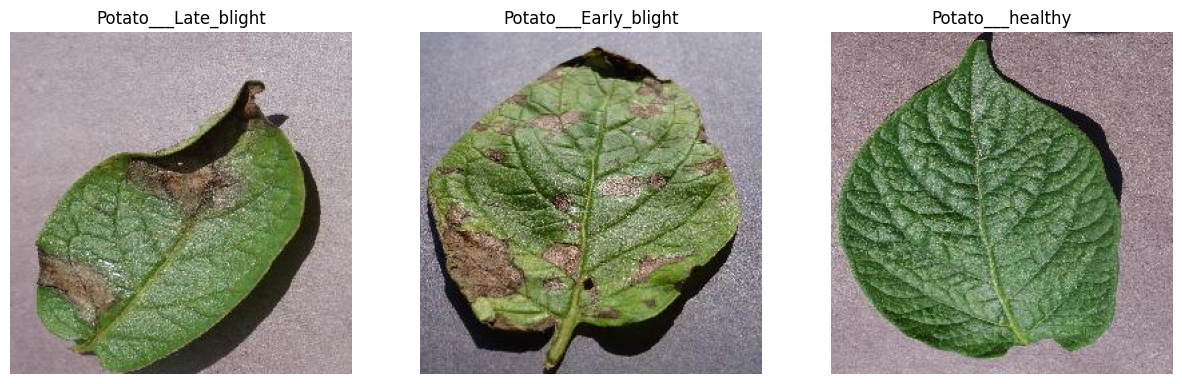

In [153]:
plt.figure(figsize=(15,5))
classes =os.listdir(train_path)
for i, folder in enumerate(classes):
    image_name = os.listdir(os.path.join(train_path,folder))[0]
    image_path = os.path.join(train_path,folder,image_name)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    plt.subplot(1,3,i+1)
    plt.imshow(image)
    plt.title(folder)
    plt.axis("off")
plt.show()

In [154]:
train_path = "/content/Plant_Disease_Workshop/train"
val_path = "/content/Plant_Disease_Workshop/val"
image_size = (64,64)

In [155]:
X_train = []
y_train = []

X_val = []
y_val = []

In [156]:
for label in os.listdir(train_path):
  folder_path = os.path.join(train_path,label)
  for image in os.listdir(folder_path):
    image_path = os.path.join(folder_path,image)
    image = cv2.imread(image_path)
    image = cv2.resize(image,image_size)
    X_train.append(image)
    y_train.append(label)
print("Training Images Loaded Successfully")




Training Images Loaded Successfully


In [157]:
for label in os.listdir(val_path):
  folder_path = os.path.join(val_path,label)
  for image in os.listdir(folder_path):
    image_path = os.path.join(folder_path,image)
    image = cv2.imread(image_path)
    image = cv2.resize(image,image_size)
    X_val.append(image)
    y_val.append(label)
print(" Validation  Images Loaded Successfully")




 Validation  Images Loaded Successfully


In [158]:
print("Training Images:",len( X_train))
print("Training Labels:",len(y_train))
print()
print("Validation Images:",len(X_val))
print("Validation Labels:",len(y_val))



Training Images: 1721
Training Labels: 1721

Validation Images: 431
Validation Labels: 431


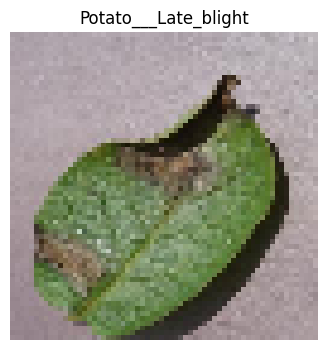

In [159]:
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(X_train[0],cv2.COLOR_BGR2RGB))
plt.title(y_train[0])
plt.axis("off")
plt.show()

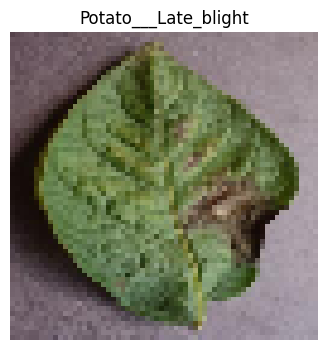

In [160]:
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(X_val[10],cv2.COLOR_BGR2RGB))
plt.title(y_val[10])
plt.axis("off")
plt.show()

In [161]:
X_train = np.array(X_train)
X_val = np.array(X_val)

y_train = np.array(y_train)
y_val = np.array(y_val)

print("Converted Successfully")

Converted Successfully


In [162]:
print("Training Shape",X_train.shape)
print("Validation Shape",X_val.shape)




Training Shape (1721, 64, 64, 3)
Validation Shape (431, 64, 64, 3)


In [163]:
X_train=X_train.reshape(X_train.shape[0],-1)
X_val=X_val.reshape(X_val.shape[0],-1)

print("Training Shape",X_train.shape)
print("Training Shape",X_val.shape)
print("Images flattened Successfully")


Training Shape (1721, 12288)
Training Shape (431, 12288)
Images flattened Successfully


In [164]:
X_train=X_train/255.0
X_val=X_val/255.0
print("Images normalization Completed")

Images normalization Completed


In [165]:
encoder=LabelEncoder()
y_train=encoder.fit_transform(y_train)
y_val=encoder.transform(y_val)
print("Labels Encoding Successfully")

Labels Encoding Successfully


In [166]:
print("Encoded Classes:")
print(encoder.classes_)
print()
print("first 10 Labels:")
print(y_train[:10])

Encoded Classes:
['Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']

first 10 Labels:
[1 1 1 1 1 1 1 1 1 1]


In [167]:
print("Training feature Shape",X_train.shape)
print("Training labelsShape",y_train.shape)
print()
print("Training feature Shape",X_val.shape)
print("Training labelsShape",y_val.shape)

Training feature Shape (1721, 12288)
Training labelsShape (1721,)

Training feature Shape (431, 12288)
Training labelsShape (431,)


In [168]:
logistic_model=LogisticRegression(max_iter=100)
print("Logistic Regression Training Completed")

Logistic Regression Training Completed


In [169]:
logistic_model.fit(X_train,y_train)
print("Logistic Regression Training Completed")

Logistic Regression Training Completed


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [170]:
y_pred=logistic_model.predict(X_val)
print("Prediction Completed")

Prediction Completed


In [171]:
print("Actual labels:",y_val[:10])
print("Predicted labels:",y_pred[:10])

Actual labels: [1 1 1 1 1 1 1 1 1 1]
Predicted labels: [1 1 1 1 1 1 1 1 1 1]


In [172]:
acc = accuracy_score(y_val,y_pred)
print("Accuracy:",round(acc*100,2),"%")

Accuracy: 89.79 %


In [173]:
cmx=confusion_matrix(y_val,y_pred)
print(cmx)

[[181  19   0]
 [  7 190   3]
 [  0  15  16]]


In [174]:
print(classification_report(y_val,y_pred,target_names=encoder.classes_))

                       precision    recall  f1-score   support

Potato___Early_blight       0.96      0.91      0.93       200
 Potato___Late_blight       0.85      0.95      0.90       200
     Potato___healthy       0.84      0.52      0.64        31

             accuracy                           0.90       431
            macro avg       0.88      0.79      0.82       431
         weighted avg       0.90      0.90      0.89       431



In [175]:
predicted_labels = encoder.inverse_transform(y_pred[:10])
print("Predicted labels:")
print(predicted_labels)

Predicted labels:
['Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight' 'Potato___Late_blight' 'Potato___Late_blight'
 'Potato___Late_blight']


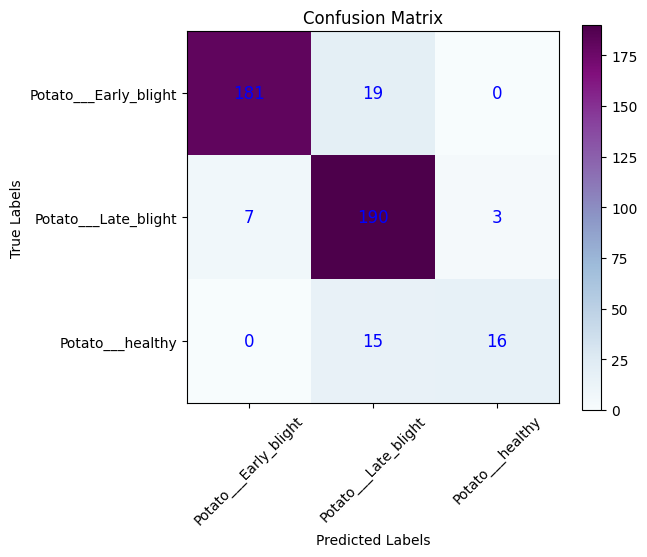

In [178]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cmx,cmap="BuPu")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(3),encoder.classes_,rotation=45)
plt.yticks(range(3),encoder.classes_)
for i in range(len(cmx)):
  for j in range(len(cmx)):
    plt.text(j,i,cmx[i][j],
    ha="center",
    va="center",
    color="blue",
    fontsize=12)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")

In [183]:
print("="*40)
print("Logistic Regression Completed Successfully")
print("="*40)
print(f"Accuracy:{acc*100:.2f}%")

Logistic Regression Completed Successfully
Accuracy:89.79%


In [184]:
svm_model = SVC(kernel="linear")
print("SVM model created!")

SVM model created!


In [186]:
svm_model.fit(X_train,y_train)
print("SVM model created!")

SVM model created!


In [187]:
y_pred = svm_model.predict(X_val)
print("Prediction Completed!")

Prediction Completed!


In [190]:
ACC=accuracy_score(y_val,y_pred)
print("Accuracy:",round(ACC*100,2),"%")

Accuracy: 91.18 %


In [191]:
cmx=confusion_matrix(y_val,y_pred)
print(cmx)

[[183  17   0]
 [  9 188   3]
 [  1   8  22]]


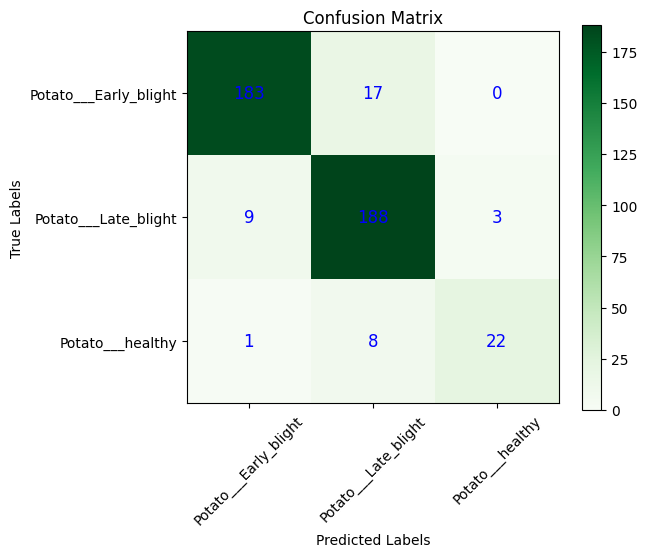

In [193]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cmx,cmap="Greens")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(3),encoder.classes_,rotation=45)
plt.yticks(range(3),encoder.classes_)
for i in range(len(cmx)):
  for j in range(len(cmx)):
    plt.text(j,i,cmx[i][j],
    ha="center",
    va="center",
    color="blue",
    fontsize=12)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")

In [197]:
print("="*40)
print("SVM Completed Successfully")
print("="*40)
print(f"Accuracy:{acc*100:.2f}%")

SVM Completed Successfully
Accuracy:89.79%


In [222]:
from google.colab import files
uploaded=files.upload()

Saving soy.jpg to soy (1).jpg


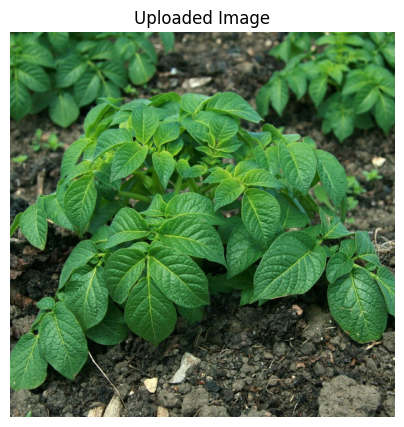

In [223]:
image_name=list(uploaded.keys())[0]
image=cv2.imread(image_name)
image_rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(image_rgb)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

In [219]:
test_image=cv2.resize(image,(64,64))
test_image=test_image.reshape(1,-1)
test_image=test_image/255.0
print(" image Preprocessed successfully")

 image Preprocessed successfully


In [220]:
prediction=svm_model.predict(test_image)
predicted_diseases=encoder.inverse_transform(prediction)
print("Prediction Diseases:",predicted_diseases[0])

Prediction Diseases: Potato___Late_blight


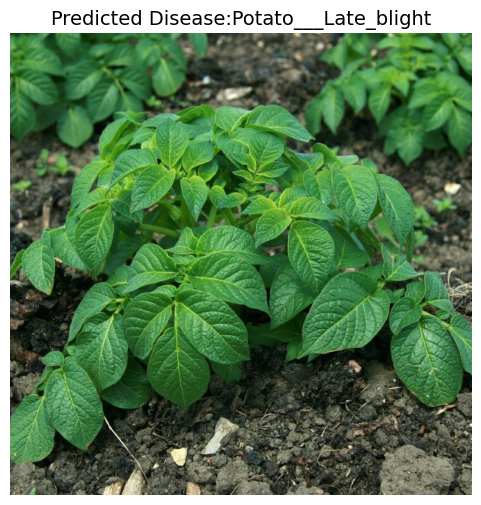

In [224]:
plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("Predicted Disease:"+predicted_diseases[0],fontsize=14)
plt.axis("off")
plt.show()

In [229]:
if predicted_diseases[0]== "Potato___Early_blight":
  print("Disease :Potato___Early_blight")
  print("Advice:Remove infected leaves and apply  suitable fungicide.")

elif predicted_diseases[0]== "Potato___Late_blight":
  print("Disease :Potato___Late_blight")
  print("Advice:Improve drainage, avoid overhead watering, and recommended .")
elif predicted_diseases[0]== "Potato___healthy":
  print("Potato___healthy")
  print("Advice:No action required")

Disease :Potato___Late_blight
Advice:Improve drainage, avoid overhead watering, and recommended .


In [230]:
comparison={
    "model":["Logistic Regression","SVM"],
    "accuracy":[acc*100,ACC*100]
}
import pandas as pd
comparison_df=pd.DataFrame(comparison)
comparison_df

,model,accuracy
0,Logistic Regression,89.791183
1,SVM,91.183295


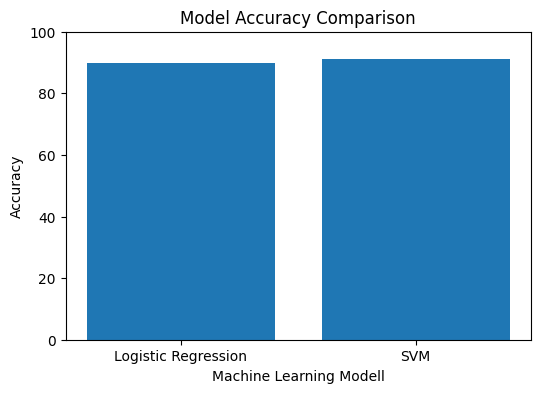

In [234]:
plt.figure(figsize=(6, 4))
plt.bar(comparison_df["model"],comparison_df["accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Modell")
plt.ylabel("Accuracy")
plt.ylim(0, 100)
plt.show()

In [241]:
if ACC>acc:
  print("SVM is better")
else:
  print("Logistic Regression is better")

SVM is better
